In [1]:
import numpy as np

euler_cube = np.load('./output/euler_cube.npy')
coord_cube = np.load('./output/coord_cube.npy')
Nb_cube = np.load('./output/Nb_cube.npy')
Sn_cube = np.load('./output/Sn_cube.npy')
# shifted_points = np.load('./output/points.npy')
points = np.load('./output/points.npy')
euler_flat = np.load('./output/euler_flat.npy')
Sn_flat = np.load('./output/Sn_flat.npy')
Sn_points = np.copy(points)
phase_flat = np.load('./output/phase_flat.npy')

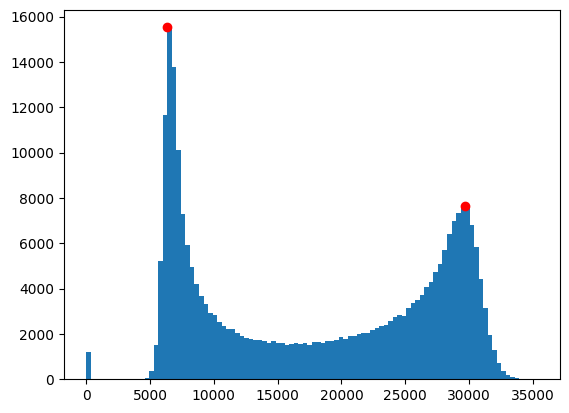

In [2]:
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

counts, bin_edges, patches = plt.hist(Sn_flat, bins=100)
peaks, _ = find_peaks(counts, height=6000)
plt.scatter(bin_edges[peaks], counts[peaks], c="red")
lower_Sn_peak, upper_Sn_peak = bin_edges[peaks]

In [3]:
"""Find the vacuum interface"""
from skimage.measure import marching_cubes
import pyvista as pv

total_xray_cube = Nb_cube + Sn_cube
total_xray_cube = np.pad(total_xray_cube, pad_width=10, mode='edge')
Nb_cube = np.pad(Nb_cube, pad_width=10, mode='edge')

# plt.hist(total_xray_cube.flatten())

verts, faces, normals, values = marching_cubes(total_xray_cube,120000,spacing=(0.1,0.1,0.1))
verts = verts - np.array((1.0,1.0,1.0))
surface_mesh = pv.PolyData.from_regular_faces(verts, faces).subdivide(1).smooth(n_iter=10, relaxation_factor=0.1, boundary_smoothing=False).compute_normals(auto_orient_normals=True).triangulate()

verts, faces, normals, values = marching_cubes(Nb_cube,165000,spacing=(0.1,0.1,0.1))
verts = verts - np.array((1.0,1.0,1.0))
substrate_mesh = pv.PolyData.from_regular_faces(verts, faces).smooth(n_iter=20, relaxation_factor=0.1, boundary_smoothing=False).compute_normals(auto_orient_normals=True).triangulate()

In [4]:
import pyvista as pv
pv.set_jupyter_backend('client')
pv.global_theme.allow_empty_mesh = True

plotter = pv.Plotter()

plotter.add_mesh(surface_mesh)
plotter.add_mesh(substrate_mesh)

plotter.show()

Widget(value='<iframe src="http://localhost:45517/index.html?ui=P_0x7d3aae8117f0_0&reconnect=auto" class="pyvi…

In [5]:
"""Find points in vacuum"""
points_pv = pv.PolyData(points)
outside_points = points_pv.select_enclosed_points(surface_mesh.extrude([-10.0,0.0,0.0], capping=True), inside_out=True)
outside_mask = outside_points['SelectedPoints'].view(np.bool_)

phase_flat[outside_mask] = 3    # 3 -> Vacuum

In [6]:
def mirror_points_across_plane(points, plane_point, plane_normal):
    """
    Reflects 3D points across a plane.

    Args:
        points: np.ndarray of shape (N, 3) - the input points.
        plane_point: np.ndarray or list of shape (3,) - a point on the plane.
        plane_normal: np.ndarray or list of shape (3,) - the normal vector of the plane.

    Returns:
        np.ndarray of shape (N, 3) - the mirrored points.
    """
    points = np.asarray(points)
    plane_point = np.asarray(plane_point)
    plane_normal = np.asarray(plane_normal)

    if points.shape[1] != 3 or plane_point.shape != (3,) or plane_normal.shape != (3,):
        raise ValueError("Input shapes are invalid. Points must be (N, 3), plane_point and plane_normal must be (3,)")

    # Normalize the normal vector
    n = plane_normal / np.linalg.norm(plane_normal)

    # Vector from plane point to each input point
    v = points - plane_point

    # Distance from point to plane along the normal
    d = np.dot(v, n)  # shape: (N,)

    # Reflect the points
    mirrored = points - 2 * np.outer(d, n)

    return mirrored

def is_outside_bounds(points, bounds):
    bounds = np.array(bounds)
    min, max = bounds.T
    return np.any(np.greater(points, max[None,:]), axis=1) | np.any(np.less(points, min[None,:]), axis=1)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.transform import Rotation


# euler_points = euler_cube.reshape(euler_cube.shape[0]*euler_cube.shape[1]*euler_cube.shape[2],euler_cube.shape[3])
euler_points = euler_flat


# coordinates = coord_cube.reshape(coord_cube.shape[0]*coord_cube.shape[1]*coord_cube.shape[2],coord_cube.shape[3])
coordinates = points

bounds = ((0.0, 0.1*coord_cube.shape[0]),
          (0.0, 0.1*coord_cube.shape[1]),
          (0.0, 0.1*coord_cube.shape[2]))
normals = np.array(
    ((1.0,0.0,0.0),
    (0.0,1.0,0.0),
    (0.0,0.0,1.0))
    )
center = tuple((b[0] + b[1]) / 2 for b in bounds)

out_of_bounds = is_outside_bounds(coordinates,bounds)
coordinates = coordinates[~out_of_bounds]
euler_points = euler_points[~out_of_bounds]

#EBSD_points = np.append(coordinates,euler_points,axis=-1)

# nonzero = list(not(np.array_equal(euler_points[i,:],np.array((0.0,0.0,0.0)))) for i in range(euler_points.shape[0]))
nonzero = phase_flat != 0
coordinates = coordinates[nonzero]
euler_points = euler_points[nonzero]
phase_flat = phase_flat[nonzero]



#coordinates = np.append(coordinates,[[100,100,100]],axis=0)
np.random.seed(0)
subsample = np.random.randint(0,coordinates.shape[0],size=50000)

euler_points = euler_points[subsample]
coordinates = coordinates[subsample]
phase_flat = phase_flat[subsample]

new_coordinates = [coordinates]
new_euler_points = [euler_points]
new_phase_flat = [phase_flat]

for axis, normal in zip(bounds,normals):
    for bound in axis:
        point = bound * normal
        mirrored_coordinates = mirror_points_across_plane(coordinates, point, normal)
        new_coordinates.append(mirrored_coordinates)
        new_euler_points.append(euler_points)
        new_phase_flat.append(phase_flat)

coordinates = np.concatenate(new_coordinates, axis=0)
euler_points = np.concatenate(new_euler_points, axis=0)
phase_flat = np.concatenate(new_phase_flat, axis=0)

outer_bounds = ((-1.0, 1.0 + 0.1*coord_cube.shape[0]),
                (-1.0, 1.0 + 0.1*coord_cube.shape[1]),
                (-1.0, 1.0 + 0.1*coord_cube.shape[2]))

is_inside_outer = ~is_outside_bounds(coordinates,outer_bounds)

coordinates = coordinates[is_inside_outer]
euler_points = euler_points[is_inside_outer]
phase_flat = phase_flat[is_inside_outer]

#plt.scatter(euler_points[:,0],euler_points[:,1],c=euler_points[:,2])

In [8]:
rotations = Rotation.from_euler('XZX',euler_points)

del euler_points

In [9]:
from scipy.spatial import Voronoi

vor = Voronoi(coordinates)

In [10]:
from scipy.sparse import csr_array

vertices = vor.vertices.copy()
ridge_vertices = vor.ridge_vertices.copy()

centroid = np.average(coordinates, axis=0)

# infinite_point = np.array((100.0,100.0,100.0))
# vertices = np.concatenate((vertices,infinite_point[None,:]),axis=0)

edges = []
ridge_edges = []
i = 0

for ridge in ridge_vertices:
    new_ridge = []
    for i, (vert1, vert2) in enumerate(zip(ridge,ridge[1:]+ridge[:1])):
        if vert1 == -1:
            new_vertex = 1e1 * (vertices[vert2] - centroid)
            vertices = np.concatenate((vertices,new_vertex[None,:]),axis=0)
            vert1 = vertices.shape[0] - 1
            ridge[i] = vert1
        if vert2 == -1:
            new_vertex = 1e1 * (vertices[vert1] - centroid)
            vertices = np.concatenate((vertices,new_vertex[None,:]),axis=0)
            vert2 = vertices.shape[0] - 1
            ridge[i] = vert2
        """create new edge"""
        new_edge = [vert1,vert2].copy()
        edges.append(new_edge)

        """add edge to ridge"""
        new_ridge.append(i)
        i += 1

    ridge_edges.append(new_ridge)

edges, inverse = np.unique(np.array(edges),axis=0,return_inverse=True)
ridge_edges = [[inverse[j] for j in ridge_edges[i]] for i in range(len(ridge_edges))]







In [11]:
region_ridges = [[] for _ in range(len(vor.regions))]

for ridge_ind, ridge in enumerate(vor.point_region[vor.ridge_points]):
    for region_ind in ridge:
        region_ridges[region_ind].append(ridge_ind)

In [12]:
T_VE = csr_array((vertices.shape[0],edges.shape[0]),dtype='bool')
T_EF = csr_array((edges.shape[0],len(ridge_edges)),dtype='bool')
T_FD = csr_array((len(ridge_edges),len(vor.regions)),dtype='bool')

In [13]:
X,Y = np.indices(edges.shape)

T_VE[edges.flatten(),X.flatten()] = True

# for i, edge in enumerate(edges):
#     T_VE[edge[0],i] = True
#     T_VE[edge[1],i] = True

/home/vike/dev/3debsd/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_array is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


In [14]:
ridge_ind = np.repeat(np.arange(len(ridge_edges)),[len(ridge_edges[i]) for i in range(len(ridge_edges))])
edge_ind = [edge for ridge in ridge_edges for edge in ridge]

T_EF[edge_ind,ridge_ind] = True

# for ridge_ind, ridge in enumerate(ridge_edges):
#     for edge in ridge:
#         T_EF[edge,ridge_ind] = True

In [15]:
ridge_ind = [ridge for region in region_ridges for ridge in region]
region_ind = np.repeat(np.arange(len(region_ridges)),[len(region_ridges[i]) for i in range(len(region_ridges))])

T_FD[ridge_ind,region_ind] = True


# for face in np.arange(0,vor.ridge_points.shape[0]):
#     for domain in vor.point_region[vor.ridge_points[face,:]]:
#         T_FD[face,domain] = True

In [16]:
DP_map = [0]*len(vor.regions)
for point, domain_ind in enumerate(vor.point_region):
    DP_map[domain_ind] = point

In [17]:


outside_domains = is_outside_bounds(coordinates[DP_map], bounds)
# T_FD = T_FD * ~outside_domains[None,:]
# T_FD.eliminate_zeros()

In [18]:
# def save_obj(filepath, verts, faces):
#     file = open(filepath, 'w')
#     for vertex in verts:
#         file.write(f"v {vertex[0]} {vertex[1]} {vertex[2]}\n")

#     for face in faces:
#         file.write(f"f ")
#         for ind in face:
#             file.write(f"{ind+1} ")
#         file.write("\n")  

#     file.close()

In [19]:
# save_obj('output/sample_surface.obj',verts,faces)

In [20]:
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# # Display resulting triangular mesh using Matplotlib. This can also be done
# # with mayavi (see skimage.measure.marching_cubes docstring).
# fig = plt.figure(figsize=(10, 10))
# ax = fig.add_subplot(111, projection='3d')

# # Fancy indexing: `verts[faces]` to generate a collection of triangles
# mesh = Poly3DCollection(verts[faces])
# mesh.set_edgecolor('k')
# ax.add_collection3d(mesh)

# ax.set_xlabel("x-axis: a = 6 per ellipsoid")
# ax.set_ylabel("y-axis: b = 10")
# ax.set_zlabel("z-axis: c = 16")

# ax.set_xlim(0, 10)  # a = 6 (times two for 2nd ellipsoid)
# ax.set_ylim(0, 10)  # b = 10
# ax.set_zlim(0, 10)  # c = 16

# plt.tight_layout()
# plt.show()

In [21]:
"""add bounding box"""

'add bounding box'

In [22]:
"""calculate intersections between domain faces and bounding surface"""

'calculate intersections between domain faces and bounding surface'

In [23]:
"""create new faces and update intersecting domains"""

'create new faces and update intersecting domains'

In [24]:
misorientations = rotations[vor.ridge_points[:,0]] * rotations[vor.ridge_points[:,1]].inv()
misorientations = np.linalg.norm(misorientations.as_rotvec(),axis=-1)

phase_boundaries = phase_flat[vor.ridge_points[:,0]] != phase_flat[vor.ridge_points[:,1]]

# GBs = [i for (i,v) in zip(vor.ridge_points,(misorientations > 0.1)) if v]
# nonGBs = [i for (i,v) in zip(vor.ridge_points,(misorientations < 0.1)) if v]

# GBs = vor.point_region[vor.ridge_points[misorientations > 0.1]]
# nonGBs = vor.point_region[vor.ridge_points[misorientations < 0.1]]



In [25]:
is_out = np.zeros(T_FD.shape[1], dtype=bool)
is_out[outside_domains] = True

T_FD = T_FD.tocsr()
T_FDout = T_FD[:, is_out]
T_FDin = T_FD[:, ~is_out]
boundary_faces = T_FDout.max(axis=1) * T_FDin.max(axis=1)

GBs = ((misorientations > 0.05) + phase_boundaries) * T_FDin.max(axis=1)
GBs = GBs + boundary_faces

In [26]:
A_DGB = csr_array((T_FD.shape[1],T_FD.shape[1]))
T_FDGB = csr_array(T_FD.shape)

T_FDGB = T_FD * GBs[:,None]
T_FDGB.eliminate_zeros()

A_DGB = T_FDGB.T @ T_FDGB
A_DGB.eliminate_zeros()
A_D = T_FD.T @ T_FD
A_D.eliminate_zeros()
A_DnonGB = A_D - A_DGB
A_DnonGB.eliminate_zeros()

In [27]:
from scipy.sparse.csgraph import breadth_first_tree

# fig = plt.figure(figsize=(10, 10))
# ax = fig.add_subplot(111)


remaining_regions = np.arange(T_FD.shape[1])[~outside_domains]
grains = []

while remaining_regions.shape[0] > 0:
    csr_grain = breadth_first_tree(A_DnonGB,remaining_regions[0],directed=False)

    csr_grain = csr_grain.tocoo()

    grain_regions = np.unique(np.concatenate((csr_grain.coords[0],csr_grain.coords[1],remaining_regions[0,None])))

    remaining_regions = np.setdiff1d(remaining_regions,grain_regions,assume_unique=True)

    grains.append(grain_regions)

    # grain_ids = [vor.regions[v] for v in grain_regions]
    # color = np.random.rand(3,)

    # ax = fig.axes[0]

    # for i, regionid in enumerate(grain_ids):

    #     # print(f"point index: {i}")
    #     # print(f"region ID: {regionid}")
        
    #     if -1 not in regionid:

    #         vertices = vor.vertices[regionid]
    #         vertices = np.asarray(vertices)
    #         ax.fill(vertices[:,0],vertices[:,1],facecolor=color)


In [28]:
# grains.append(np.arange(T_FD.shape[1])[outside_domains])


In [29]:
T_PD = csr_array((len(vor.point_region),len(vor.regions)),dtype='bool')

point_ind = np.arange((len(vor.point_region)))
domain_ind = vor.point_region

T_PD[point_ind,domain_ind] = True


In [30]:
grain_phase = []
for grain_indices in grains:
    point_ind = T_PD[:,grain_indices].nonzero()[0]
    grain_phase.append(phase_flat[point_ind])

In [31]:
T_DG = csr_array((len(vor.regions),len(grains)),dtype='bool')

grain_ind, domain_ind = np.array([[i,domain] for i, grain in enumerate(grains) for domain in grain]).T

T_DG[domain_ind,grain_ind] = True

# for i, grain in enumerate(grains):
#     for domain in grain:
#         T_DG[domain,i] = True

In [32]:
B_D = T_DG @ T_DG.T
B_D.eliminate_zeros()
subgrain_matrix = A_DGB * B_D
gb_matrix = A_DGB - subgrain_matrix
T_FG = (T_FD @ gb_matrix @ T_DG) * (T_FD @ T_DG)

In [33]:
# grain_sizes = np.array([len(grain) for grain in grains])
# small_grains = np.where(grain_sizes < 100)[0]

# A_G = T_FG.T @ T_FG
# for grain in small_grains:
#     grain_neighbors = A_G[grain, :].nonzero()[0]
#     # grain_neighbors = grain_neighbors[~np.isin(grain_neighbors, small_grains)]
#     if len(grain_neighbors) > 0:
#         largest_neighbor = np.argmax(grain_sizes[grain_neighbors])
#     else:
#         largest_neighbor = np.argmax(grain_sizes)
#     A_G[largest_neighbor, :] = A_G[[largest_neighbor], :] + A_G[[grain], :]
#     A_G[grain, :] = False
#     A_G[:, largest_neighbor] = A_G[:, [largest_neighbor]] + A_G[:, [grain]]
#     A_G[:, grain] = False
#     T_DG[:, largest_neighbor] = T_DG[:, [largest_neighbor]] + T_DG[:, [grain]]
#     T_DG[:, grain] = False

# T_DG.eliminate_zeros()

In [34]:
# B_D = T_DG @ T_DG.T
# B_D.eliminate_zeros()
# subgrain_matrix = A_DGB * B_D
# gb_matrix = A_DGB - subgrain_matrix
# T_FG = (T_FD @ gb_matrix @ T_DG) * (T_FD @ T_DG)

In [35]:
from pyvista import PolyData

def plot_grain(id) -> PolyData:
    GB_vertices = [vor.ridge_vertices[face] for face in T_FG[:,[id]].tocoo().coords[0]]

    # Create a new list without out-of-bounds vertices
    filtered_GB_vertices = []

    for face in GB_vertices:
        # Check if any vertex is -1 (indicating infinity in Voronoi diagrams)
        if -1 in face:
            continue
            
        # # Check if any vertex is out of bounds
        # verts_coords = vertices[face]
        # if verts_coords.max() > 10.0 or verts_coords.min() < 0.0:
        #     continue
            
        # If we get here, the face is valid
        filtered_GB_vertices.append(face)

    # print(f"Filtered out {len(GB_vertices) - len(filtered_GB_vertices)} faces with out-of-bounds vertices")

    # Replace the original list with the filtered one
    GB_vertices = filtered_GB_vertices

    # First, identify which vertices are actually used in GB_vertices
    used_vertices = set()
    for triangle in GB_vertices:
        for idx in triangle:
            used_vertices.add(idx)

    # Create a mapping from old indices to new indices
    old_to_new = {}
    new_vertices = []

    for i, idx in enumerate(sorted(used_vertices)):
        old_to_new[idx] = i
        new_vertices.append(vertices[idx])

    # Convert vertices to numpy array
    new_vertices = np.array(new_vertices)

    # Update the indices in GB_vertices
    new_GB_vertices = []
    for triangle in GB_vertices:
        new_triangle = [old_to_new[idx] for idx in triangle]
        new_GB_vertices.append(new_triangle)

    # print(f"Reduced vertices from {len(vertices)} to {len(new_vertices)}")

    # bounding_box = [0.2, coordinates[:,0].max()-1.2, 0.2, coordinates[:,1].max()-0.2, 0.2, coordinates[:,2].max()-0.2]
    # box = pv.Box(bounding_box, level=8)
    # roi = box.clip_surface(surface_mesh, invert=False)
    # roi += surface_mesh.clip_surface(box, invert=True)
    # roi.triangulate(inplace=True).compute_normals(inplace=True, auto_orient_normals=True)


    # roi = pv.Box(bounding_box, 4, quads=False)
    # roi = surface_mesh.extrude_trim([1,0,0], pv.Plane(i_size=50, j_size=50, direction=[1,0,0])).triangulate().compute_normals(inplace=True, auto_orient_normals=True)



    # polydata = pv.PolyData.from_irregular_faces(new_vertices, new_GB_vertices).clip_box(bounding_box, invert=False).clip_surface(surface_mesh, invert=False)
    # polydata += surface_mesh.clip_surface(polydata, invert=False)

    grain_mesh = pv.PolyData.from_irregular_faces(new_vertices, new_GB_vertices).connectivity('largest').triangulate().clean().compute_normals(auto_orient_normals=True)  
    # polydata = grain_mesh.clip_box(bounding_box, invert=False)
    # polydata = grain_mesh.boolean_intersection(roi)
    # polydata: PolyData = grain_mesh.clip_surface(surface_mesh, invert=False)
    # polydata = polydata.merge(surface_mesh.clip_surface(grain_mesh, invert=True), tolerance=0.1).triangulate()

    polydata = grain_mesh
    # polydata = grain_mesh.boolean_intersection(surface_mesh)


    return polydata
    

In [36]:
import numpy as np
import pyvista as pv
from scipy.interpolate import griddata

grain_mesh = plot_grain(24)
centroid = grain_mesh.center_of_mass()
bbox = grain_mesh.bounds

# Step 1: Create or load your point cloud (replace this with your own data)
# For demonstration, we generate a sample 3D point cloud with a scalar
points = Sn_points  # 500 random points in 3D space
scalars = Sn_flat # Example scalar

# Step 2: Define a plane through the dataset
# Define a grid in the XY plane at the average Z value
plane_z = centroid[2]
grid_x, grid_y = np.meshgrid(np.linspace(bbox[0], bbox[1], 100), np.linspace(bbox[2], bbox[3], 100))
grid_z = np.full_like(grid_x, plane_z)
grid_points = np.c_[grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]

# Step 3: Interpolate the scalar values onto the plane
interpolated_scalars = griddata(points, scalars, grid_points, method='linear')



In [37]:
# Step 4: Create a PyVista StructuredGrid
# Reshape the grid points and scalars to 2D grid
structured_grid = pv.StructuredGrid()
structured_grid.points = np.c_[grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]
structured_grid.dimensions = grid_x.shape + (1,)
structured_grid["interpolated_scalar"] = interpolated_scalars

import pyvista as pv
pv.set_jupyter_backend('client')
pv.global_theme.allow_empty_mesh = True

plotter = pv.Plotter()

colors = np.random.rand(len(grains),3)
plane_color = pv.Color(opacity=0.5)

plotter.add_mesh(structured_grid.clip_surface(grain_mesh), scalars="interpolated_scalar", cmap="viridis", show_edges=False)
plotter.add_mesh(grain_mesh.clip_surface(structured_grid), color=colors[10],opacity=1.0)

plotter.show()

Widget(value='<iframe src="http://localhost:45517/index.html?ui=P_0x7d3a7f67c410_1&reconnect=auto" class="pyvi…

In [38]:
structured_grid = structured_grid.compute_implicit_distance(grain_mesh)
structured_grid['distance'] = structured_grid['implicit_distance']

import pyvista as pv
pv.set_jupyter_backend('client')
pv.global_theme.allow_empty_mesh = True

plotter = pv.Plotter()

colors = np.random.rand(len(grains), 3)
plane_color = pv.Color(opacity=0.5)

plotter.add_mesh(structured_grid, scalars="distance", cmap="viridis", show_edges=False, opacity=0.9)
plotter.add_mesh(grain_mesh.clip_surface(structured_grid), color=colors[10], opacity=1.0)

plotter.show()

Widget(value='<iframe src="http://localhost:45517/index.html?ui=P_0x7d3a7f67dd10_2&reconnect=auto" class="pyvi…

ValueError: autodetected range of [nan, nan] is not finite

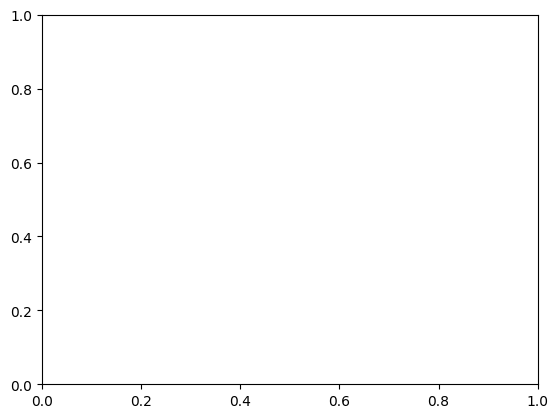

In [39]:
import matplotlib.pyplot as plt

inside_mask = structured_grid['distance'] < 0

plt.hist2d(-structured_grid['distance'][inside_mask], (structured_grid['interpolated_scalar'][inside_mask]-lower_Sn_peak)/(upper_Sn_peak-lower_Sn_peak), bins=20)

In [ ]:
grid = pv.StructuredGrid(Sn_points).compute_implicit_distance(surface_mesh)
grid['surface_distance'] = grid['implicit_distance']

x0 = 0.052160687644751465, k = 7.607975611668005, c= 0.5432469900407253


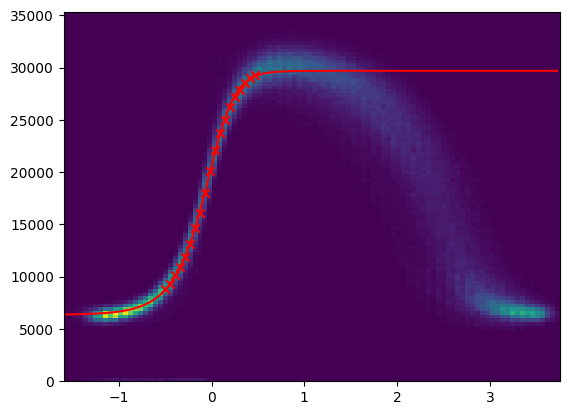

In [ ]:


H, xedges, yedges = np.histogram2d(grid['implicit_distance'], Sn_flat, bins=[100, 100])

# Bin centers
x_centers = 0.5 * (xedges[:-1] + xedges[1:])
y_centers = 0.5 * (yedges[:-1] + yedges[1:])

xmin = -0.5
xmax = 0.5

# Create a boolean mask
mask = (x_centers >= xmin) & (x_centers <= xmax)

# Apply the mask to x_centers and avg_composition
x_masked = x_centers[mask]

# Convert histogram to average composition per x-bin
avg_composition = []

masked_indices = np.where(mask)[0]

for i in masked_indices:
    # counts along the y-axis at this x
    counts = H[i, :]
    if np.sum(counts) == 0:
        avg_composition.append(np.nan)
    else:
        # Weighted average composition
        avg = np.sum(counts * y_centers) / np.sum(counts)
        avg_composition.append(avg)

avg_composition = np.array(avg_composition)

plt.pcolormesh(x_centers, y_centers, H.T)
plt.scatter(x_masked,avg_composition, c="red", marker="x")

from scipy.optimize import curve_fit

def skew_sigmoid(x, L, x0, k, b, c):
    return L * (1 / (1 + np.exp(-k*(x - x0))))**c + b
# Remove NaNs
mask = ~np.isnan(avg_composition)
x_fit_data = x_masked[mask]
y_fit_data = avg_composition[mask]

# Initial guess
p0 = [0, 1, 1]

fit_func = lambda x, x0, k, c: skew_sigmoid(x, upper_Sn_peak-lower_Sn_peak, x0, k, lower_Sn_peak, c)
params, _ = curve_fit(fit_func, x_fit_data, y_fit_data, p0=p0, maxfev=10000)
x_plot = np.linspace(np.min(x_centers), np.max(x_centers), 200)
y_plot = fit_func(x_plot, *params)
plt.plot(x_plot,y_plot, c="red")

print(f"x0 = {params[0]}, k = {params[1]}, c= {params[2]}")

surface_correction = lambda x: fit_func(x, *params)



In [ ]:
grid = grid.compute_implicit_distance(substrate_mesh)

grid['substrate_distance'] = grid['implicit_distance']

KeyboardInterrupt: 

: 

x0 = 0.28976919314406313, k = -3.595575856576228, c = 3.244669010391865


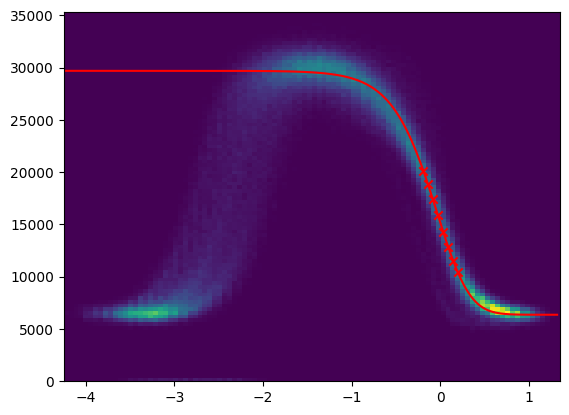

In [ ]:
H, xedges, yedges = np.histogram2d(grid['implicit_distance'], Sn_flat, bins=[100, 100])

# Bin centers
x_centers = 0.5 * (xedges[:-1] + xedges[1:])
y_centers = 0.5 * (yedges[:-1] + yedges[1:])

xmin = -0.25
xmax = 0.25

# Create a boolean mask
mask = (x_centers >= xmin) & (x_centers <= xmax)

# Apply the mask to x_centers and avg_composition
x_masked = x_centers[mask]

# Convert histogram to average composition per x-bin
avg_composition = []

masked_indices = np.where(mask)[0]

for i in masked_indices:
    # counts along the y-axis at this x
    counts = H[i, :]
    if np.sum(counts) == 0:
        avg_composition.append(np.nan)
    else:
        # Weighted average composition
        avg = np.sum(counts * y_centers) / np.sum(counts)
        avg_composition.append(avg)

avg_composition = np.array(avg_composition)

plt.pcolormesh(x_centers, y_centers, H.T)
plt.scatter(x_masked,avg_composition, c="red", marker="x")

from scipy.optimize import curve_fit

# Remove NaNs
mask = ~np.isnan(avg_composition)
x_fit_data = x_masked[mask]
y_fit_data = avg_composition[mask]

# Initial guess
p0 = [0, 1, 1]

fit_func = lambda x, x0, k, c: skew_sigmoid(x, upper_Sn_peak-lower_Sn_peak, x0, k, lower_Sn_peak, c)
params, _ = curve_fit(fit_func, x_fit_data, y_fit_data, p0=p0, maxfev=10000)
x_plot = np.linspace(np.min(x_centers), np.max(x_centers), 200)
y_plot = fit_func(x_plot, *params)
plt.plot(x_plot,y_plot, c="red")

print(f"x0 = {params[0]}, k = {params[1]}, c = {params[2]}")

substrate_correction = lambda x: fit_func(x, *params)

In [ ]:
H_total = np.zeros((50,100))
all_points = []
all_Sn_delta = []

for id, grain in enumerate([grains[i] for i in [0,1,2,3,4,5,6,7,8]]):
    if len(grain) < 100:
        continue
    if (grain_phase[id] == 3).any():
        continue
    if (grain_phase[id] == 1).any():
        continue
    
    grain_mesh = plot_grain(id)

    grid = grid.compute_implicit_distance(grain_mesh)
    inside_mask = grid['implicit_distance'] < 0.0

    closer_to_surface = np.abs(grid['surface_distance'][inside_mask]) < np.abs(grid['substrate_distance'][inside_mask])
    Sn_delta = (closer_to_surface * surface_correction(grid['surface_distance'][inside_mask]) + ~closer_to_surface * substrate_correction(grid['substrate_distance'][inside_mask])) - Sn_flat[inside_mask]

    all_points.append(Sn_points[inside_mask])
    all_Sn_delta.append(Sn_delta)

    H, x_edges, y_edges = np.histogram2d(grid['implicit_distance'][inside_mask], Sn_delta, bins=(50,100))

    H_total += H

all_points = np.concatenate(all_points)
all_Sn_delta = np.concatenate(all_Sn_delta)


NameError: name 'grid' is not defined

In [40]:
import pyvista as pv
pv.set_jupyter_backend('client')
pv.global_theme.allow_empty_mesh = True


# plot_mesh = pv.PolyData.from_irregular_faces(new_vertices, new_GB_vertices)
# plot_mesh.plot(cpos='xy', show_edges=True)

plotter = pv.Plotter()

colors = np.random.rand(len(grains),3)



# for id in range(T_DG.shape[1] - 1):
for id in range(len(grains)):
    if (grain_phase[id] == 3).any():
        continue
    if (grain_phase[id] == 1).any():
        continue
    if T_DG[:,[id]].tocoo().coords[0].shape[0] > 10:
        plotter.add_mesh(plot_grain(id).rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), color=colors[id], opacity=1.0)


# Sn_mask = (all_Sn_delta < -2_000) * (all_Sn_delta > -5_000)

# Sn_deficient_points = pv.PolyData(all_points[Sn_mask])
# Sn_deficient_points['Sn_count'] = all_Sn_delta[Sn_mask]

# plotter.add_points(Sn_deficient_points, scalars=Sn_deficient_points['Sn_count'], point_size=5)
# plotter.enable_eye_dome_lighting()
# plotter.enable_shadows()
plotter.enable_ssao(kernel_size=256, radius=0.5)

# Create a light
light = pv.Light()
light.position = (500, 500, -300)         # Set light position
light.focal_point = (center[0], center[2], center[1])       # Point it at the origin
light.intensity = 0.5
light.color = (1.0, 1.0, 1.0)  # white

# Add the light to the plotter
plotter.add_light(light)

plotter.camera_position = [
    (20, 15, -25),   # Camera location
    (center[0], center[1], 0),      # Look at origin
    (0, 0, 1)       # Up is in +Z direction
]

plotter.screenshot(f"output/output.png", scale=2.0)  # 2x resolution


pyvista_ndarray([[[251, 251, 251],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [252, 252, 252]],

                 [[255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255]],

                 [[255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255]],

                 ...,

                 [[255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255]],

                 [[255, 255, 255],
  

In [62]:
import numpy as np
import pyvista as pv
from scipy.interpolate import griddata

bbox = bounds

# Step 1: Create or load your point cloud (replace this with your own data)
# For demonstration, we generate a sample 3D point cloud with a scalar
points = Sn_points  # 500 random points in 3D space
scalars = Sn_flat # Example scalar

# Step 2: Define a plane through the dataset
# Define a grid in the XY plane at the average Z value
plane_x = 2.7
grid_y, grid_z = np.meshgrid(np.linspace(bbox[1][0]-0.1, bbox[1][1]+0.1, 100), np.linspace(bbox[2][0]-0.1, bbox[2][1]+0.1, 100))
grid_x = np.full_like(grid_y, plane_x)
grid_points = np.c_[grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]

# Step 3: Interpolate the scalar values onto the plane
interpolated_scalars = griddata(points, scalars, grid_points, method='linear')

# Step 4: Create a PyVista StructuredGrid
# Reshape the grid points and scalars to 2D grid
structured_grid = pv.StructuredGrid()
structured_grid.points = np.c_[grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]
structured_grid.dimensions = grid_x.shape + (1,)
structured_grid["interpolated_scalar"] = interpolated_scalars



In [63]:
dist = []
count = []

for id in range(T_DG.shape[1] - 1):
    if (grain_phase[id] == 3).any():
        continue
    if (grain_phase[id] == 1).any():
        continue
    if T_DG[:,[id]].tocoo().coords[0].shape[0] > 10:
        grain_mesh = plot_grain(id)
        intersection = grain_mesh.intersection(structured_grid.extract_surface().triangulate(), split_first=False, split_second=False)[0]

        if intersection.n_points > 0:

            inside_grid = structured_grid.clip_surface(grain_mesh)

            if inside_grid.n_points > 0:

                point_distances = inside_grid.compute_implicit_distance(grain_mesh)['implicit_distance']

                dist.append(point_distances)
                count.append(inside_grid['interpolated_scalar'])

dist = np.concatenate(dist)
count = np.concatenate(count)

valid_mask = ~(np.isnan(dist)+np.isnan(count))

dist = dist[valid_mask]
count = count[valid_mask]





2025-09-19 16:09:33.590 (1368.704s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:34.305 (1369.419s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:34.394 (1369.508s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:34.418 (1369.532s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:34.639 (1369.753s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:34.782 (1369.896s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:34.940 (1370.054s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:35.269 (1370.382s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09

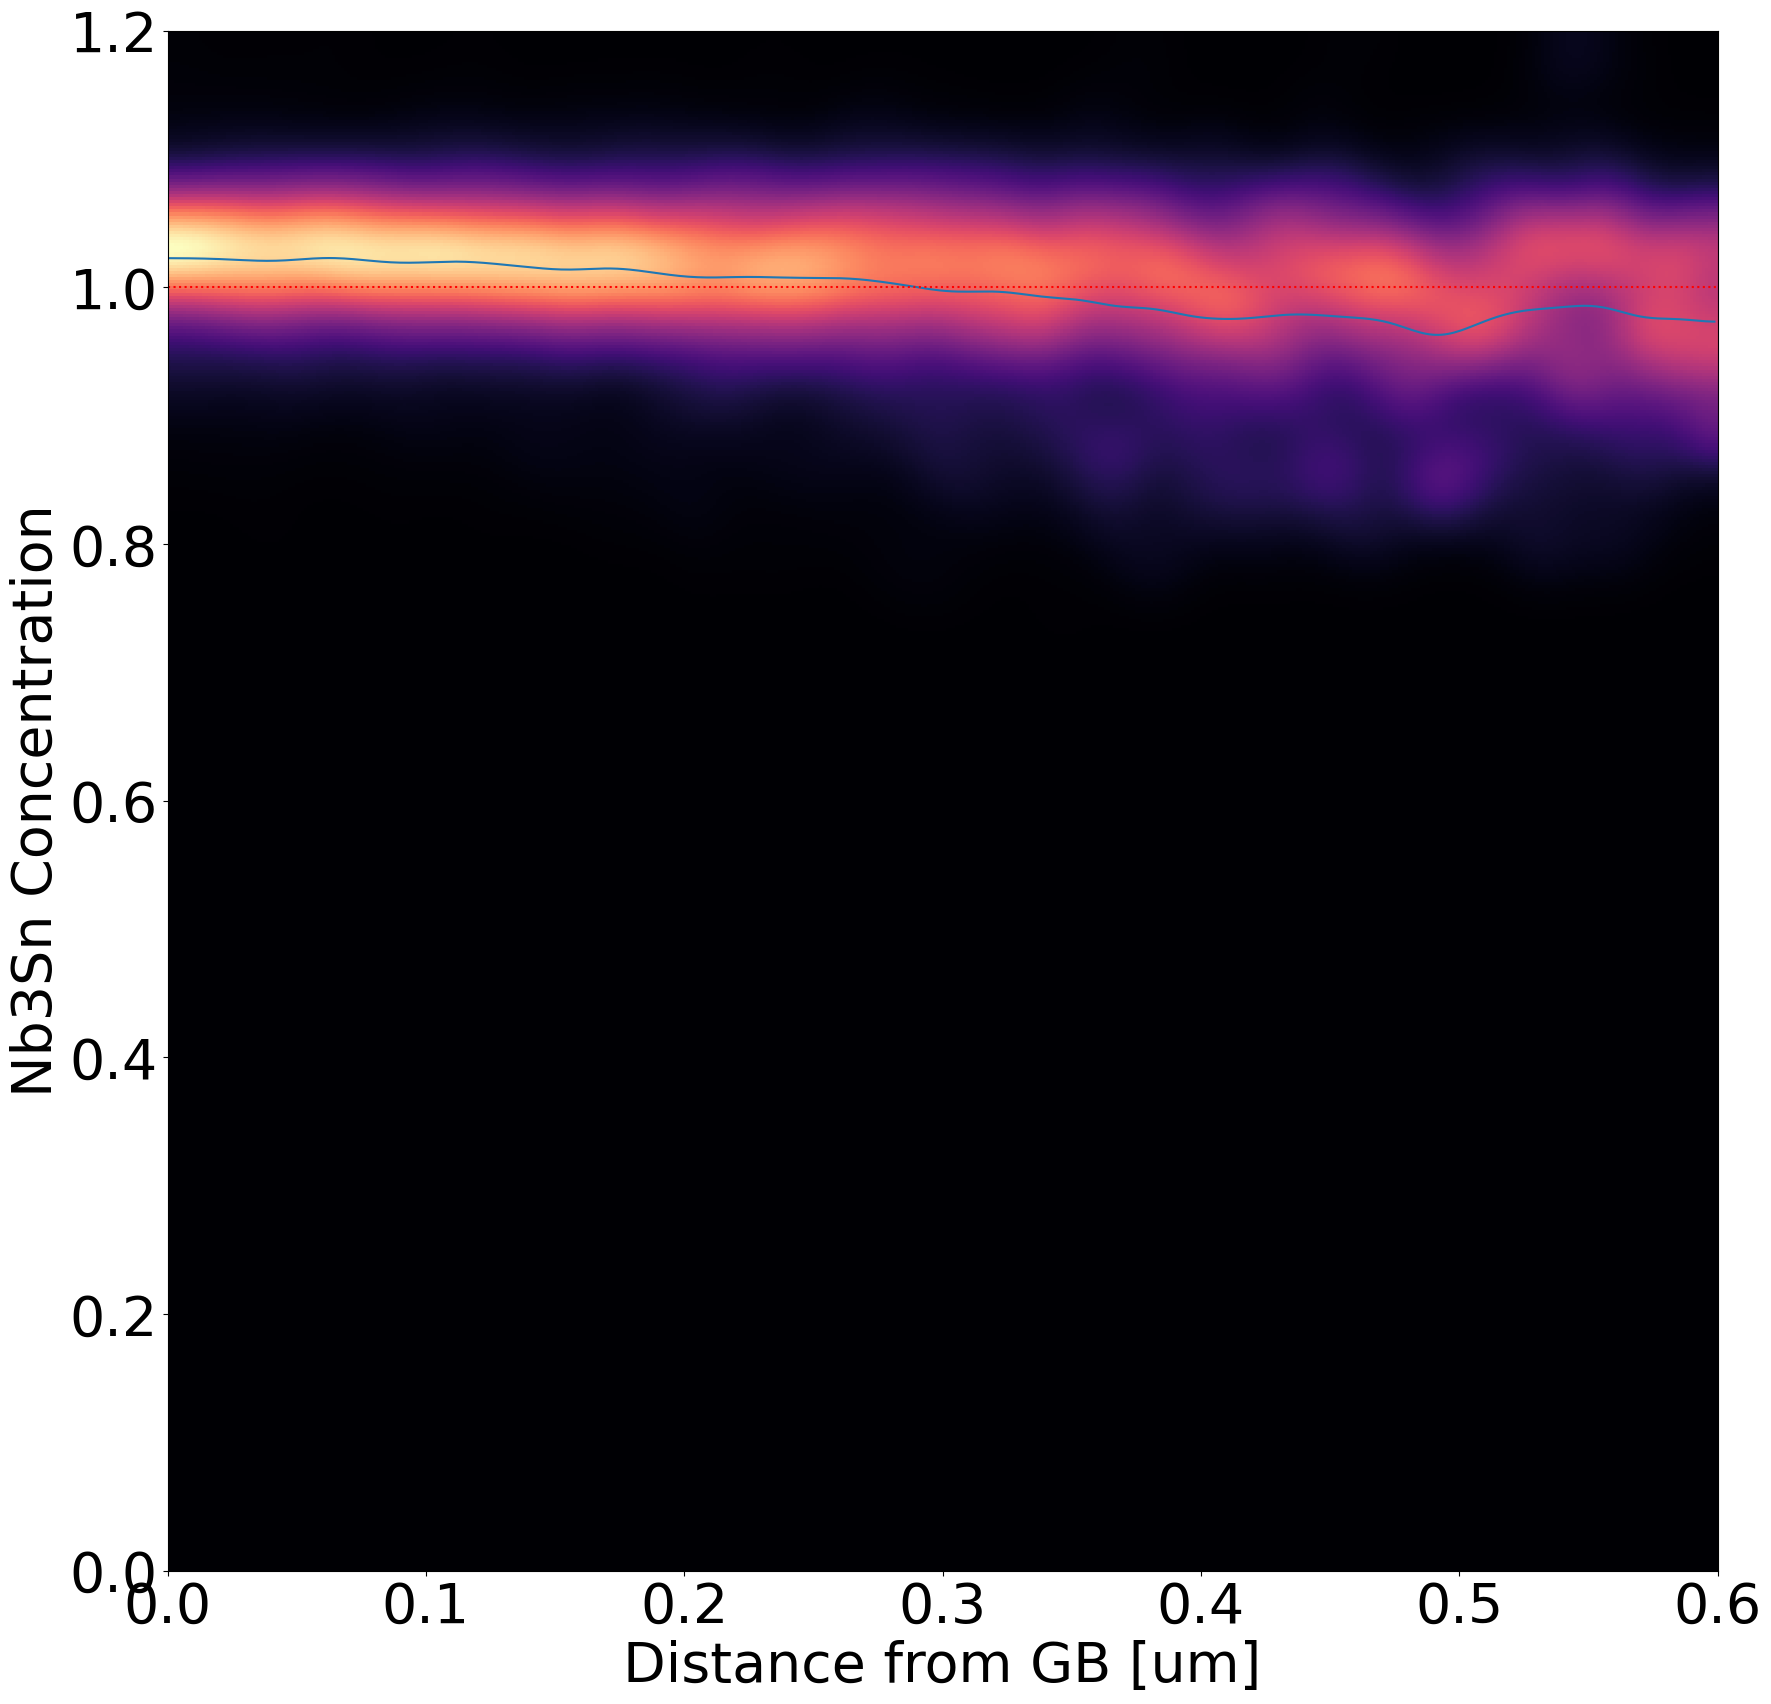

In [64]:
from scipy.ndimage import gaussian_filter

# Define bin edges
x_bins = np.linspace(0.0,0.6, 501)   # 100 bins in x
y_bins = np.linspace(0.0,1.2, 501)   # 100 bins in y

# Compute 2D histogram
H, x_edges, y_edges = np.histogram2d(np.abs(dist), (count-lower_Sn_peak)/(upper_Sn_peak-lower_Sn_peak), bins=[x_bins, y_bins])

# Normalize each column so it sums to 1
H_norm = H / (H.sum(axis=1, keepdims=True) + 1e-12)  # avoid division by zero

H_norm = gaussian_filter(H_norm, 10.0)

y_avg = np.sum(H_norm*y_bins[None,:-1],axis=1) / np.sum(H_norm,axis=1)

# Plot
plt.rcParams.update({'font.size': 40})
plt.figure(figsize=(20, 20))

plt.pcolormesh(x_edges, y_edges, H_norm.T, shading='auto', cmap="magma")  # transpose H for correct orientation
plt.plot(x_bins[:-1],y_avg)
plt.hlines(1.0,0.0,0.6,colors="r",linestyles=":")

plt.xlabel('Distance from GB [um]')
plt.ylabel('Nb3Sn Concentration')
# plt.colorbar(label='Normalized count per column')
plt.savefig(f"output/hist_section_{plane_x}um.png")
plt.show()


In [65]:
import pyvista as pv
pv.set_jupyter_backend('client')
pv.global_theme.allow_empty_mesh = True

plotter = pv.Plotter(off_screen=True, window_size=(1920, 1080))


colors = np.random.rand(len(grains),3)
plane_color = pv.Color(opacity=0.5)

plotter.add_mesh(structured_grid.rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), scalars="interpolated_scalar", cmap="viridis", show_edges=False, opacity=1.0)
for id in range(T_DG.shape[1] - 1):

    if (grain_phase[id] == 3).any():
        continue
    # if (grain_phase[id] == 1).any():
    #     continue
    if T_DG[:,[id]].tocoo().coords[0].shape[0] > 10:
        grain_mesh = plot_grain(id)
        plotter.add_mesh(grain_mesh.intersection(structured_grid.extract_surface().triangulate(), split_first=False, split_second=False)[0].rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), line_width=4)
        plotter.add_mesh(grain_mesh.clip_surface(structured_grid).rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), color=colors[id])
        plotter.add_mesh(grain_mesh.clip_surface(structured_grid, invert=False).rotate_y(-90).rotate_z(180).translate([0.1,0.1+bounds[1][1],0.1]), color=colors[id],opacity=0.1)

plotter.show_grid(
    color='gray',
    xtitle='X [um]',
    ytitle='Y [um]',
    ztitle='Z [um]',
    show_xaxis=True,
    show_yaxis=True,
    show_zaxis=True,
    location='outer',  # or 'back'
    font_size=40
)

plotter.camera_position = [
    (20, 15, 25),   # Camera location
    (center[0], center[1], 0),      # Look at origin
    (0, 0, 1)       # Up is in +Z direction
]
plotter.remove_scalar_bar()

plotter.screenshot(f"output/3d_section_{plane_x}um.png", scale=2.0)  # 2x resolution


2025-09-19 16:09:37.899 (1373.013s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:38.590 (1373.703s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:39.410 (1374.524s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:39.554 (1374.667s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:39.607 (1374.720s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:39.955 (1375.069s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:40.167 (1375.281s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09:40.359 (1375.473s) [    7D3B8FDB2100]vtkIntersectionPolyData:2423  WARN| No Intersection between objects 
2025-09-19 16:09

pyvista_ndarray([[[255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255]],

                 [[255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255]],

                 [[255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255]],

                 ...,

                 [[255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [255, 255, 255]],

                 [[255, 255, 255],
  

Text(0.5, 0, 'Grain Diameter [um]')

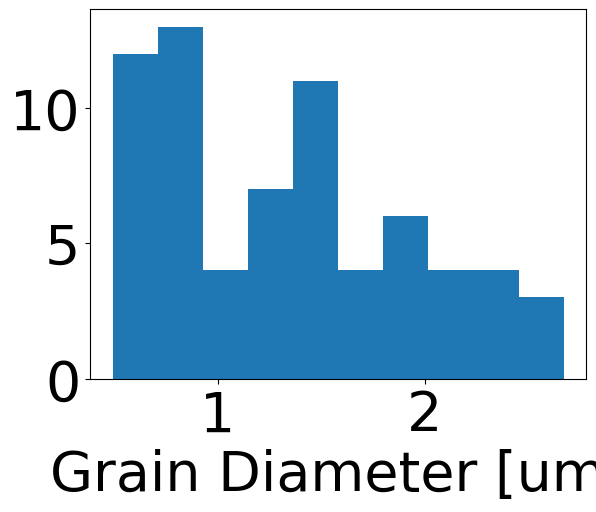

In [66]:
grain_volume = []

for id in range(T_DG.shape[1] - 1):
    if (grain_phase[id] == 3).any():
        continue
    if (grain_phase[id] == 1).any():
        continue
    if T_DG[:,[id]].tocoo().coords[0].shape[0] > 10:
        grain_mesh = plot_grain(id)
        
        grain_volume.append(grain_mesh.volume)

grain_volume = np.array(grain_volume)

grain_diameter = 2*((3*grain_volume)/(4*np.pi))**(1/3)

plt.hist(grain_diameter, bins=10)
plt.xlabel("Grain Diameter [um]")

In [67]:
centroid = np.average(coordinates, axis=0)

def save_grain(id):

    GB_vertices = [ridge_vertices[face] for face in T_FG[:,[id]].tocoo().coords[0]]

    # Create a new list without out-of-bounds vertices
    filtered_GB_vertices = []

    for face in GB_vertices:
        # Check if any vertex is -1 (indicating infinity in Voronoi diagrams)
        for i, vertex in enumerate(face):
            if vertex == -1:
                continue
            
        # # Check if any vertex is out of bounds
        # verts_coords = vertices[face]
        # if verts_coords.max() > 10.0 or verts_coords.min() < 0.0:
        #     continue
            
        # If we get here, the face is valid
        filtered_GB_vertices.append(face)
    
    print(f"Filtered out {len(GB_vertices) - len(filtered_GB_vertices)} faces with out-of-bounds vertices")

    # Replace the original list with the filtered one
    GB_vertices = filtered_GB_vertices

    # First, identify which vertices are actually used in GB_vertices
    used_vertices = set()
    for triangle in GB_vertices:
        for idx in triangle:
            used_vertices.add(idx)

    # Create a mapping from old indices to new indices
    old_to_new = {}
    new_vertices = []

    for i, idx in enumerate(sorted(used_vertices)):
        old_to_new[idx] = i
        new_vertices.append(vertices[idx])

    # Convert vertices to numpy array
    new_vertices = np.array(new_vertices)

    # Update the indices in GB_vertices
    new_GB_vertices = []
    for triangle in GB_vertices:
        new_triangle = [old_to_new[idx] for idx in triangle]
        new_GB_vertices.append(new_triangle)

    print(f"Reduced vertices from {len(vertices)} to {len(new_vertices)}")


    save_obj(f'output/grain{id}.obj',new_vertices,new_GB_vertices)
    

for i in range(T_FG.shape[1]):
    if T_DG[:,[i]].tocoo().coords[0].shape[0] > 100:
        # for face in T_FG[:,[i]].tocoo().coords[0]:
        #     if -1 not in vor.ridge_vertices[face]:
        #         GB_vertices.extend(vor.ridge_vertices[face])
        #     else:
        #         ridge_vertices = vor.ridge_vertices[face].copy()
                

        # for face in range(len(GB_vertices)):
        #     GB_vert_coords.extend(vertices[GB_vertices[face]])

        # # GB_vertices = [vor.ridge_vertices[face] if -1 not in vor.ridge_vertices[face] else [] for face in T_FG[:,[i]].tocoo().coords[0]]
        # # GB_vert_coords = [vertices[GB_vertices[face]] for face in range(len(GB_vertices))]

        # faces = GB_vertices
        # verts = vertices

        # save_obj(f'output/grain{i}.obj',verts,faces)

        save_grain(i)

Filtered out 0 faces with out-of-bounds vertices
Reduced vertices from 398630 to 1931


NameError: name 'save_obj' is not defined

In [ ]:
import pyvista as pv

def unstructured_grid_from_grain(id):
    domains = T_DG[:,[id]].nonzero()[0]
    T_VD = T_VE @ T_EF @ T_FD
    cell_types = [pv.CellType.POLYHEDRON] * len(domains)
    
    used_vertices = set()
    cell_point_ids = []

    for domain in domains:
        vertex_indices = T_VD[:,domain].nonzero()[0]
        used_vertices.update(vertex_indices)

        cell_point_ids.append(vertex_indices)


    index_map = {old_idx: new_idx for new_idx, old_idx in enumerate(sorted(used_vertices))}

    cell_array = []
    for cell in cell_point_ids:
        new_cell = [index_map[pt] for pt in cell]
        cell_array.append(len(new_cell))
        cell_array.extend(new_cell)

    cells = cell_array
    points = vertices[sorted(used_vertices)]

    print(cells)

    bounding_box = [0, coordinates[:,0].max(), 0, coordinates[:,1].max(), 0, coordinates[:,2].max()]
    roi = pv.Box(bounds=bounding_box)
    grid = pv.UnstructuredGrid(cells, cell_types, points)

    return grid, roi


In [ ]:
# import pyvista as pv
# pv.set_jupyter_backend('client')
# pv.global_theme.allow_empty_mesh = True

# plotter = pv.Plotter()
# T_VF = T_VE @ T_EF
# T_VD = T_VE @ T_EF @ T_FD
# colors = np.random.rand(len(grains),3)
# # for id in range(len(grains)):
# for id in [10,]:
#     if T_DG[:,[id]].tocoo().coords[0].shape[0] > 0:
#         domains = T_DG[:,[id]].nonzero()[0]
        
#         cell_types = [pv.CellType.POLYHEDRON] * len(domains)
        
#         used_vertices = set()
#         cell_point_ids = []

#         for domain in domains:
#             vertex_indices = T_VD[:,domain].nonzero()[0]
#             used_vertices.update(vertex_indices)

#             cell_point_ids.append(vertex_indices)


#         index_map = {old_idx: new_idx for new_idx, old_idx in enumerate(sorted(used_vertices))}

#         cell_list = []
#         for domain in domains:
#             faces = []
#             for face in T_FD[:, domain].nonzero()[0]:
#                 face_indices = T_VF[:, face].nonzero()[0]

#                 new_face = [index_map[pt] for pt in face_indices]
#                 new_face = [len(new_face), *new_face]

#                 faces.append(new_face)

#             new_cell = [x for face in faces for x in face]
#             new_cell = [len(faces), *new_cell]

#             cell_list.append(new_cell)


#         cells = [x for cell in cell_list for x in cell]
#         cells = [len(cell_list), *cells]

#         points = vertices[sorted(used_vertices)]

#         print(len(cells))

#         bounding_box = [0, coordinates[:,0].max(), 0, coordinates[:,1].max(), 0, coordinates[:,2].max()]
#         roi = pv.Box(bounds=bounding_box)
#         grid = pv.UnstructuredGrid(cells, [pv.CellType.POLYHEDRON], points)
#         plotter.add_mesh(grid, color=colors[id], show_edges=True)
#         plotter.add_mesh(roi, color='gray', opacity=0.5, show_edges=True)

# plotter.show()

In [ ]:
from scipy.spatial import KDTree

tree = KDTree(coordinates)
query_points = coord_cube.reshape(coord_cube.shape[0]*coord_cube.shape[1]*coord_cube.shape[2],coord_cube.shape[3])

dd, ii = tree.query(query_points)

In [ ]:
query_point_ids = np.arange(ii.shape[0])
query_domain_ids = vor.point_region[ii]


T_QD = csr_array((query_points.shape[0],len(vor.regions)),dtype='bool')
T_QD[query_point_ids,query_domain_ids] = True

/home/vike/dev/3debsd/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_array is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


In [ ]:
T_QG = T_QD @ T_DG

In [ ]:
import sys
import importlib
import plots3d
importlib.reload(sys.modules['plots3d'])
from plots3d import Scatter3D



Scatter3D(query_points[T_QG[:,3].coords[0]])

ModuleNotFoundError: No module named 'plots3d'

In [ ]:
def surf_distance(query_points, vertices, edges, faces):
    """Calculate the unsigned distance from the query points to a mesh using a kdtree approach.
    
    Parameters:
    -----------
    query_points : (N,3) array
        The coordinates of N points to calculate the distance to the mesh from.
    vertices : (M,3) array
        The coordinates of the M vertices that define the mesh.
    edges : (M,E) matrix of boolean
        A matrix defining which vertices constitute which edges.
    faces : (E,F) matrix of boolean
        A matrix defining which edges constitute which faces.

    Returns:
    --------
    distances : (N) array
        The closest distance between each of N points to the mesh.
    """


    search_tree = KDTree(vertices)

    # To first approximation, the closest distance to the 
    # mesh is the distance to the nearest vertex of the mesh.
    dd, ii = search_tree.query(query_points) 

    distances = dd

    return distances
    

In [ ]:
surf_distance(query_points[T_QG[:,3].coords[0]],)